# xPass Tutorial — SkillCorner edition


## 0. Setup


In [1]:
from pathlib import Path
import json
import os
import sys
import urllib.request as request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# ===== Data source toggle =====
DATA_SOURCE = "opendata"   # "opendata" (public 10-match sample) or "local" (your SkillCorner bundle)

LOCAL_SKILLCORNER_ROOT = os.environ.get("SKILLCORNER_ROOT")
LOCAL_SKILLCORNER_ROOT = Path(LOCAL_SKILLCORNER_ROOT) if LOCAL_SKILLCORNER_ROOT else None
LOCAL_SEASON_NAMES = None
LOCAL_LIMIT_MATCHES = None
LOCAL_LIMIT_MATCHES_PER_SEASON = None
LOCAL_PASSES_PARQUET = os.environ.get("SKILLCORNER_XPASS_PASSES_PARQUET")
LOCAL_PASSES_PARQUET = Path(LOCAL_PASSES_PARQUET) if LOCAL_PASSES_PARQUET else None

PITCH_X, PITCH_Y = 105.0, 68.0
GOAL_X, GOAL_Y = PITCH_X / 2.0, 0.0

root = Path.cwd().resolve()
for p in [root, *root.parents]:
    if (p / "xpass").exists() and (p / "xg").exists():
        root = p
        break
for p in [root, root / "football-cdf"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

OPENDATA_BASE = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches"
OPENDATA_MATCH_IDS = [1886347, 1899585, 1925299, 1953632, 1996435,
                      2006229, 2011166, 2013725, 2015213, 2017461]
OPENDATA_CACHE = root / "tmp/data/skillcorner_opendata"


def require_local_root() -> Path:
    if LOCAL_SKILLCORNER_ROOT is None:
        raise ValueError(
            "Set LOCAL_SKILLCORNER_ROOT or the SKILLCORNER_ROOT environment variable "
            "when DATA_SOURCE='local'."
        )
    return Path(LOCAL_SKILLCORNER_ROOT)


def to_px(x): return np.asarray(x, dtype=float) + PITCH_X / 2.0
def to_py(y): return np.asarray(y, dtype=float) + PITCH_Y / 2.0


def new_pitch(half=False, figsize=(9.0, 6.0)):
    pitch = Pitch(pitch_type="custom", pitch_length=PITCH_X, pitch_width=PITCH_Y,
                  half=half, pitch_color="none", line_color="#3b3b3b", linewidth=1.3,
                  goal_type="box", corner_arcs=True, line_zorder=2)
    fig, ax = pitch.draw(figsize=figsize)
    return pitch, fig, ax


print("DATA_SOURCE =", DATA_SOURCE)


DATA_SOURCE = opendata


## 1. Build a pass table from Dynamic Events

Passes are `player_possession` events whose `end_type == "pass"`. The mapping matches `xpass.skillcorner_passes`:

- **passer location:** `x_end`, `y_end`.
- **target location:** `player_targeted_x_pass`, `player_targeted_y_pass`.
- **completion label:** `pass_outcome == "successful"`.
- **provider benchmark:** `player_targeted_xpass_completion`.


### 1-1. Inspect one raw Dynamic Events match


In [2]:
def opendata_match(mid):
    OPENDATA_CACHE.mkdir(parents=True, exist_ok=True)
    base = f"{OPENDATA_BASE}/{mid}"
    ev_path = OPENDATA_CACHE / f"{mid}_dynamic_events.csv"
    mj_path = OPENDATA_CACHE / f"{mid}_match.json"
    if not ev_path.exists():
        request.urlretrieve(f"{base}/{mid}_dynamic_events.csv", ev_path)
    if not mj_path.exists():
        request.urlretrieve(f"{base}/{mid}_match.json", mj_path)
    meta = json.load(open(mj_path))
    return pd.read_csv(ev_path, low_memory=False), float(meta["pitch_length"]), float(meta["pitch_width"])


def local_match(match_id=None):
    from xpass.skillcorner_passes import load_match_index, resolve_match_context
    idx = load_match_index(require_local_root(), season_names=LOCAL_SEASON_NAMES)
    if LOCAL_LIMIT_MATCHES is not None:
        idx = idx.head(int(LOCAL_LIMIT_MATCHES))
    row = idx.iloc[0] if match_id is None else idx[idx["match_id"].eq(str(match_id))].iloc[0]
    ctx = resolve_match_context(require_local_root(), row["match_id"], match_dir=row.get("match_dir"))
    events = pd.read_csv(ctx.event_path, low_memory=False)
    meta = ctx.match_metadata
    return events, float(meta["pitch_length"]), float(meta["pitch_width"]), str(row["match_id"])


if DATA_SOURCE == "opendata":
    ev, pl, pw = opendata_match(OPENDATA_MATCH_IDS[0]); ex_label = f"open data {OPENDATA_MATCH_IDS[0]}"
elif DATA_SOURCE == "local":
    ev, pl, pw, ex_id = local_match(); ex_label = f"local SkillCorner {ex_id}"
else:
    raise ValueError("DATA_SOURCE must be 'opendata' or 'local'")

print(f"{ex_label}: {len(ev):,} events x {ev.shape[1]} columns | pitch {pl} x {pw}")
print("Top player_possession end_type values; passes are end_type == 'pass':")
display(ev.loc[ev["event_type"].eq("player_possession"), "end_type"].value_counts().head(8))
peek = ["event_type", "end_type", "x_end", "y_end", "player_targeted_x_pass", "player_targeted_y_pass",
        "pass_outcome", "player_targeted_xpass_completion"]
display(ev[ev["end_type"].eq("pass")][[c for c in peek if c in ev.columns]].head(8))


open data 1886347: 5,079 events x 294 columns | pitch 104.0 x 68.0
Top player_possession end_type values; passes are end_type == 'pass':


end_type
pass               902
possession_loss     48
shot                23
foul_suffered       15
clearance            9
unknown              2
Name: count, dtype: int64

,event_type,end_type,x_end,y_end,player_targeted_x_pass,player_targeted_y_pass,pass_outcome,player_targeted_xpass_completion
0,player_possession,pass,0.73,0.49,-21.72,0.22,successful,NaN
1,player_possession,pass,-22.21,2.70,-20.36,17.69,successful,0.9865
5,player_possession,pass,-10.75,24.18,16.91,9.27,unsuccessful,0.4683
14,player_possession,pass,-23.05,13.87,-10.82,30.43,successful,0.9947
19,player_possession,pass,-9.03,32.31,3.17,23.48,unsuccessful,0.5228
24,player_possession,pass,-37.82,-28.89,-27.20,-15.40,unsuccessful,0.5851
31,player_possession,pass,34.81,27.85,37.89,29.34,successful,0.5988
39,player_possession,pass,44.67,26.21,38.42,3.94,unsuccessful,0.4737


### 1-2. Extract pass rows


open data 1886347: passes 886 | completion 0.825 | provided xPass 0.94


,passer_x,passer_y,target_x,target_y,pass_completed,skillcorner_xpass
0,0.737019,0.49,-22.524519,1.22,True,NaN
1,-22.423558,2.70,-17.769231,20.17,True,0.9865
5,-10.853365,24.18,17.072596,9.27,False,0.4683
14,-23.271635,13.87,-9.924519,32.04,True,0.9947
19,-9.116827,32.31,3.200481,23.48,False,0.5228
24,-38.183654,-28.89,-27.461538,-15.40,False,0.5851


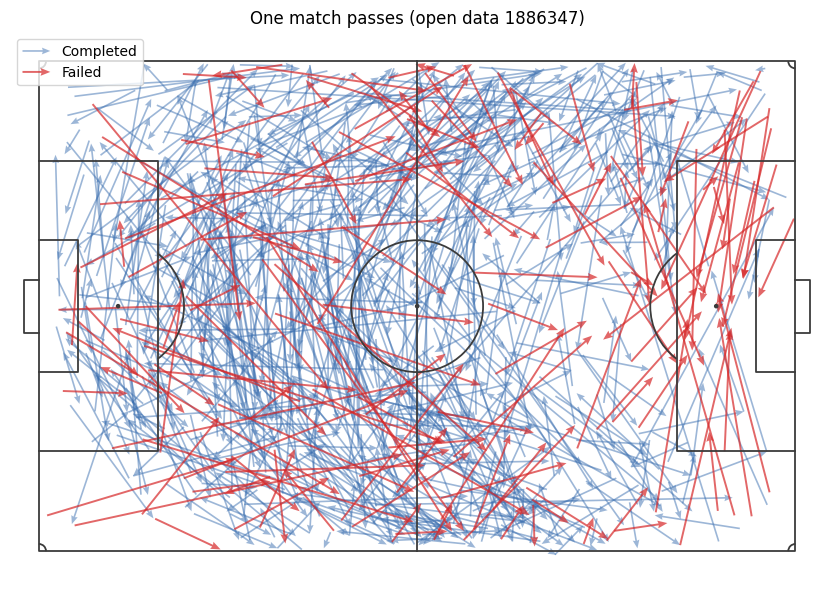

In [3]:
def passes_from_events(events, pitch_length, pitch_width):
    p = events[(events["event_type"] == "player_possession") & (events["end_type"] == "pass")].copy()
    sx, sy = PITCH_X / float(pitch_length), PITCH_Y / float(pitch_width)

    def numeric_col(col):
        if col not in p.columns:
            return pd.Series(np.nan, index=p.index)
        return pd.to_numeric(p[col], errors="coerce")

    target_pass_x = numeric_col("player_targeted_x_pass")
    target_pass_y = numeric_col("player_targeted_y_pass")
    target_reception_x = numeric_col("player_targeted_x_reception")
    target_reception_y = numeric_col("player_targeted_y_reception")

    p["passer_x"] = numeric_col("x_end") * sx
    p["passer_y"] = numeric_col("y_end") * sy
    p["target_x"] = target_reception_x.where(target_reception_x.notna(), target_pass_x) * sx
    p["target_y"] = target_reception_y.where(target_reception_y.notna(), target_pass_y) * sy
    p["possession_start_x"] = numeric_col("x_start") * sx
    p["possession_start_y"] = numeric_col("y_start") * sy
    p["pass_completed"] = p["pass_outcome"].eq("successful")
    p["skillcorner_xpass"] = numeric_col("player_targeted_xpass_completion")
    # Modelling target: clear success/failure outcomes with valid target coordinates.
    p = p[p["pass_outcome"].isin(["successful", "unsuccessful"])]
    p = p.dropna(subset=["passer_x", "passer_y", "target_x", "target_y"])
    return p


mp = passes_from_events(ev, pl, pw)
print(f"{ex_label}: passes {len(mp)} | completion {mp['pass_completed'].mean():.3f} | provided xPass {mp['skillcorner_xpass'].notna().mean():.2f}")
display(mp[["passer_x", "passer_y", "target_x", "target_y", "pass_completed", "skillcorner_xpass"]].head(6))

pitch, fig, ax = new_pitch(half=False, figsize=(9, 6))
c = mp["pass_completed"].astype(bool)
pitch.arrows(to_px(mp.loc[c, "passer_x"]), to_py(mp.loc[c, "passer_y"]),
             to_px(mp.loc[c, "target_x"]), to_py(mp.loc[c, "target_y"]),
             ax=ax, color="#3b6fb0", width=1.2, headwidth=4, alpha=0.5, label="Completed")
pitch.arrows(to_px(mp.loc[~c, "passer_x"]), to_py(mp.loc[~c, "passer_y"]),
             to_px(mp.loc[~c, "target_x"]), to_py(mp.loc[~c, "target_y"]),
             ax=ax, color="#d62728", width=1.4, headwidth=4, alpha=0.7, label="Failed")
ax.legend(loc="upper left"); ax.set_title(f"One match passes ({ex_label})")
plt.show()


### 1-3. Expand to all matches


In [4]:
if DATA_SOURCE == "opendata":
    frames = []
    for mid in OPENDATA_MATCH_IDS:
        ev_i, pl_i, pw_i = opendata_match(mid)
        pi = passes_from_events(ev_i, pl_i, pw_i)
        pi["match_id"] = str(mid); pi["season_name"] = "2024/2025"
        for col in ["player_name", "player_id", "team_id", "team_shortname", "player_targeted_position"]:
            if col not in pi.columns and col in ev_i.columns:
                pi[col] = ev_i.loc[pi.index, col]
        frames.append(pi)
    passes = pd.concat(frames, ignore_index=True)
    if "team_shortname" not in passes.columns:
        passes["team_shortname"] = passes.get("team_id", pd.Series(index=passes.index)).astype("string")
    USE_SEASON_SPLIT = False
else:
    if LOCAL_PASSES_PARQUET is not None:
        passes = pd.read_parquet(LOCAL_PASSES_PARQUET)
    else:
        from xpass.skillcorner_passes import build_skillcorner_pass_table
        passes = build_skillcorner_pass_table(
            require_local_root(),
            season_names=LOCAL_SEASON_NAMES,
            limit_matches=LOCAL_LIMIT_MATCHES,
            limit_matches_per_season=LOCAL_LIMIT_MATCHES_PER_SEASON,
        )
    passes = passes[passes["pass_outcome"].isin(["successful", "unsuccessful"])].copy()
    passes = passes.dropna(subset=["passer_x", "passer_y", "target_x", "target_y"])
    USE_SEASON_SPLIT = True

passes["pass_completed"] = passes["pass_completed"].astype(bool)
if "season_name" not in passes.columns:
    passes["season_name"] = "local"
print(f"{len(passes):,} passes | matches {passes['match_id'].nunique()} | "
      f"seasons {sorted(passes['season_name'].astype(str).unique())} | season-split={USE_SEASON_SPLIT}")
print(f"overall completion rate: {passes['pass_completed'].mean():.3f}")


8,433 passes | matches 10 | seasons ['2024/2025'] | season-split=False
overall completion rate: 0.803


## 2. Explore the data


Pass completion rate: 0.8029
Provided xPass coverage: 0.929


season_name
2024/2025    8433
Name: passes, dtype: int64

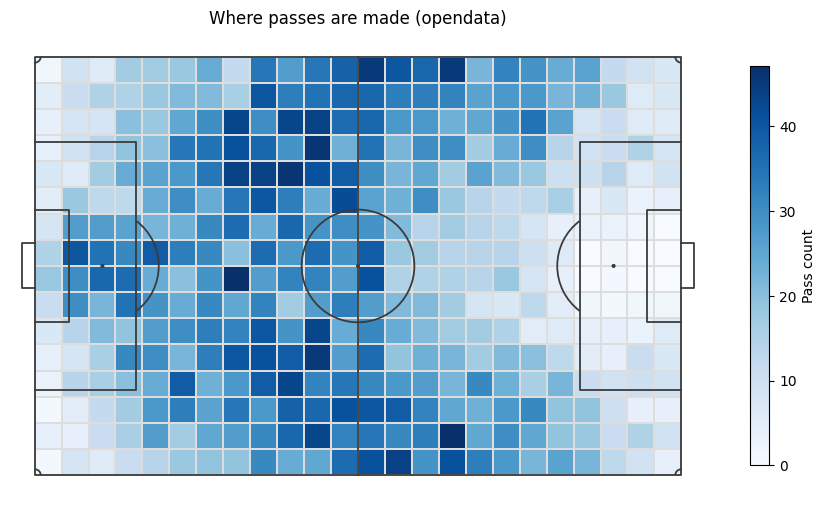

In [5]:
print("Pass completion rate:", round(passes["pass_completed"].mean(), 4))
print("Provided xPass coverage:", round(passes["skillcorner_xpass"].notna().mean(), 3))
display(passes["season_name"].astype(str).value_counts().rename("passes"))

pitch, fig, ax = new_pitch(half=False, figsize=(9, 6))
stat = pitch.bin_statistic(to_px(passes["passer_x"]), to_py(passes["passer_y"]), statistic="count", bins=(24, 16))
pcm = pitch.heatmap(stat, ax=ax, cmap="Blues", edgecolors="#dddddd", lw=0.1, zorder=1)
fig.colorbar(pcm, ax=ax, shrink=0.7, label="Pass count")
ax.set_title(f"Where passes are made ({DATA_SOURCE})")
plt.show()


## 3. Core intuition — what makes a pass difficult?

Longer passes and more progressive passes are generally harder to complete. We can see that by grouping the data before fitting any model.


/tmp/ipykernel_2540084/3399940539.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes["pass_progression"] = passes["target_x"] - passes["passer_x"]


,passes,completion
pass_distance,,
"(0, 5]",337,0.727
"(5, 10]",1879,0.811
"(10, 15]",2144,0.832
"(15, 25]",2672,0.847
"(25, 40]",1110,0.704
"(40, 120]",288,0.608


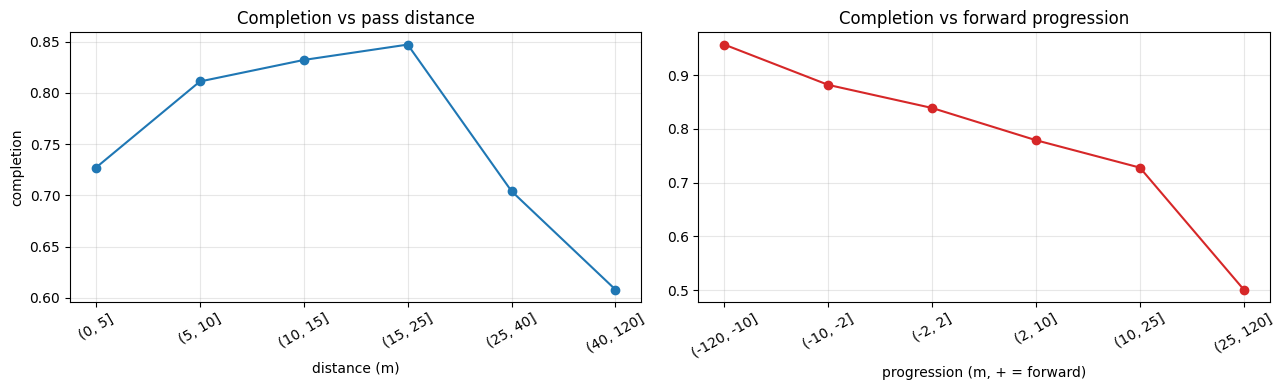

In [6]:
passes["pass_distance"] = np.hypot(passes["target_x"] - passes["passer_x"], passes["target_y"] - passes["passer_y"])
passes["pass_progression"] = passes["target_x"] - passes["passer_x"]

dist_bins = [0, 5, 10, 15, 25, 40, 120]
by_dist = (passes.groupby(pd.cut(passes["pass_distance"], dist_bins), observed=True)["pass_completed"]
                  .agg(passes="size", completion="mean").round(3))
display(by_dist)

prog_bins = [-120, -10, -2, 2, 10, 25, 120]
by_prog = (passes.groupby(pd.cut(passes["pass_progression"], prog_bins), observed=True)["pass_completed"]
                  .agg(passes="size", completion="mean").round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([str(i) for i in by_dist.index], by_dist["completion"], "o-", color="#1f77b4")
axes[0].set_title("Completion vs pass distance"); axes[0].set_xlabel("distance (m)"); axes[0].set_ylabel("completion"); axes[0].tick_params(axis="x", rotation=30); axes[0].grid(alpha=.3)
axes[1].plot([str(i) for i in by_prog.index], by_prog["completion"], "o-", color="#d62728")
axes[1].set_title("Completion vs forward progression"); axes[1].set_xlabel("progression (m, + = forward)"); axes[1].tick_params(axis="x", rotation=30); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()


## 4. Build features by hand

In addition to distance and progression, we use pass **angle** (straight forward is near 0; backward approaches pi), passer position, lateral width, and whether the target is inside the box.


In [7]:
dx = passes["target_x"] - passes["passer_x"]
dy = passes["target_y"] - passes["passer_y"]
passes["pass_angle"] = np.arctan2(dy.abs(), dx)             # 0=straight forward, pi=backward
passes["abs_passer_y"] = passes["passer_y"].abs()
passes["target_in_box"] = ((passes["target_x"] >= GOAL_X - 16.5) & (passes["target_y"].abs() <= 20.16)).astype(int)
display(passes[["pass_distance", "pass_progression", "pass_angle", "passer_x", "abs_passer_y", "target_in_box", "pass_completed"]].head())


/tmp/ipykernel_2540084/3739418437.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes["abs_passer_y"] = passes["passer_y"].abs()
/tmp/ipykernel_2540084/3739418437.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes["target_in_box"] = ((passes["target_x"] >= GOAL_X - 16.5) & (passes["target_y"].abs() <= 20.16)).astype(int)


,pass_distance,pass_progression,pass_angle,passer_x,abs_passer_y,target_in_box,pass_completed
0,23.272990,-23.261538,3.110221,0.737019,0.49,0,True
1,18.079371,4.654327,1.310426,-22.423558,2.70,0,True
2,31.657028,27.925962,0.490408,-10.853365,24.18,0,False
3,22.545385,13.347115,0.937245,-23.271635,13.87,0,True
4,15.155361,12.317308,0.621964,-9.116827,32.31,0,False


## 5. Train an xPass model — XGBoost

As in the xG tutorial, we use shallow, regularized XGBoost trees and relax the settings for small public samples. Feature importance gives a quick read on what the model used most.


In [8]:
from xgboost import XGBClassifier

def make_xgb(n_train):
    small = n_train < 2000
    return XGBClassifier(
        n_estimators=300 if small else 450, max_depth=3,
        learning_rate=0.05 if small else 0.035,
        subsample=0.9 if small else 0.85, colsample_bytree=0.9 if small else 0.85,
        min_child_weight=1 if small else 8, reg_lambda=1.0 if small else 2.0,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=4, random_state=42, tree_method="hist",
    )

seasons = sorted(passes["season_name"].astype(str).unique())
if USE_SEASON_SPLIT and len(seasons) >= 2:
    test_season = seasons[-1]
    train_mask = passes["season_name"].astype(str).ne(test_season)
    test_mask  = passes["season_name"].astype(str).eq(test_season)
    split_desc = f"train seasons {seasons[:-1]} / test season {test_season}"
else:
    mids = sorted(passes["match_id"].astype(str).unique())
    n_test = max(1, len(mids) // 3); test_ids = set(mids[-n_test:])
    test_mask = passes["match_id"].astype(str).isin(test_ids); train_mask = ~test_mask
    split_desc = f"train {len(mids)-n_test} matches / test {n_test} matches (single season)"

print(split_desc); print(f"train {int(train_mask.sum()):,} / test {int(test_mask.sum()):,} passes")

feat_simple = ["pass_distance", "pass_progression"]
m1 = make_xgb(int(train_mask.sum()))
m1.fit(passes.loc[train_mask, feat_simple], passes.loc[train_mask, "pass_completed"].astype(int))
print("\nfeature importance:")
for f, imp in sorted(zip(feat_simple, m1.feature_importances_), key=lambda t: -t[1]):
    print(f"  {f:18s} {imp:.3f}")
passes["xpass_simple"] = np.nan
passes.loc[test_mask, "xpass_simple"] = m1.predict_proba(passes.loc[test_mask, feat_simple])[:, 1]

train 7 matches / test 3 matches (single season)
train 6,036 / test 2,397 passes

feature importance:
  pass_progression   0.680
  pass_distance      0.320


/tmp/ipykernel_2540084/2710110213.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes["xpass_simple"] = np.nan


## 6. Evaluation

Passes are completed much more often than shots become goals, so accuracy is not enough. We use log loss, Brier score, AUC, and the sum of predicted completions.


In [11]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

def report(y, p, name):
    y = np.asarray(y, dtype=int); p = np.asarray(p, dtype=float)
    print(f"{name:24s} log_loss={log_loss(y, p, labels=[0,1]):.4f}  "
          f"Brier={brier_score_loss(y, p):.4f}  AUC={roc_auc_score(y, p):.4f}  "
          f"sum(xPass)={p.sum():7.1f}  completed={int(y.sum())}")

y_test = passes.loc[test_mask, "pass_completed"].astype(int)
report(y_test, passes.loc[test_mask, "xpass_simple"], "distance + progression")
baseline = np.full(int(test_mask.sum()), passes.loc[train_mask, "pass_completed"].mean())
report(y_test, baseline, "baseline (constant)")

distance + progression   log_loss=0.5298  Brier=0.1730  AUC=0.6632  sum(xPass)= 1939.5  completed=1829
baseline (constant)      log_loss=0.5573  Brier=0.1839  AUC=0.5000  sum(xPass)= 1962.6  completed=1829


## 7. Calibration


,passes,pred,actual
0,240,0.519,0.554
1,240,0.702,0.608
2,240,0.761,0.750
3,239,0.790,0.753
4,243,0.813,0.761
5,236,0.836,0.763
6,240,0.865,0.775
7,239,0.897,0.874
8,242,0.937,0.864
9,238,0.973,0.929


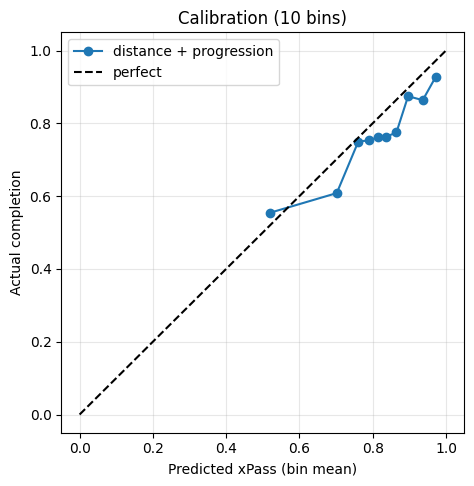

In [12]:
def calibration_table(y, p, q):
    d = pd.DataFrame({"y": np.asarray(y, int), "p": np.asarray(p, float)})
    d["bin"] = pd.qcut(d["p"], q, duplicates="drop")
    return (d.groupby("bin", observed=True)
              .agg(passes=("y", "size"), pred=("p", "mean"), actual=("y", "mean")).reset_index(drop=True))

n_bins = min(10, max(3, int(test_mask.sum()) // 200))
cal = calibration_table(y_test, passes.loc[test_mask, "xpass_simple"], n_bins)
display(cal.round(3))
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(cal["pred"], cal["actual"], "o-", color="#1f77b4", label="distance + progression")
ax.plot([0, 1], [0, 1], "k--", label="perfect")
ax.set_xlabel("Predicted xPass (bin mean)"); ax.set_ylabel("Actual completion")
ax.set_title(f"Calibration ({n_bins} bins)"); ax.legend(); ax.grid(alpha=.3); plt.show()

## 8. Add richer SkillCorner features and compare with SkillCorner xPass

First train a compact angle/location model for readability. Then reuse the package feature pipeline from `xpass.xpass_features` and `xpass.train_skillcorner_xpass`, which adds the richer SkillCorner Dynamic Events context used by the reusable code: target geometry, possession context, passing options, defensive-line context, phase/game-state fields, pass type flags, and categorical player/zone descriptors when those columns exist.


/tmp/ipykernel_2540084/551236461.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes.loc[test_mask, "xpass_rich"] = m2.predict_proba(passes.loc[test_mask, feat_rich])[:, 1]
/tmp/ipykernel_2540084/551236461.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes.loc[test_mask, "xpass_module_rich"] = m3.predict_proba(passes_featured.loc[test_mask, xpass_module_features])[:, 1]


distance + progression   log_loss=0.5298  Brier=0.1730  AUC=0.6632  sum(xPass)= 1939.5  completed=1829
+ angle / position / box log_loss=0.4886  Brier=0.1578  AUC=0.7478  sum(xPass)= 1936.2  completed=1829
module rich features     log_loss=0.2930  Brier=0.0908  AUC=0.9207  sum(xPass)= 1871.4  completed=1829

module feature columns: 67 total (36 numeric, 19 binary, 12 categorical)
numeric inputs populated in this data: ['passer_x', 'passer_y', 'target_x', 'target_y', 'abs_passer_y', 'pass_progression', 'duration', 'distance_covered', 'speed_avg', 'n_passing_options', 'n_off_ball_runs', 'n_passing_options_line_break', 'n_passing_options_first_line_break', 'n_passing_options_second_last_line_break', 'n_passing_options_last_line_break', 'n_passing_options_ahead', 'n_teammates_ahead_start', 'n_opponents_ahead_player_in_possession_pass_moment', 'n_opponents_bypassed', 'n_opponents_ahead_start', 'last_defensive_line_x_start', 'delta_to_last_defensive_line_start', 'last_defensive_line_height_s

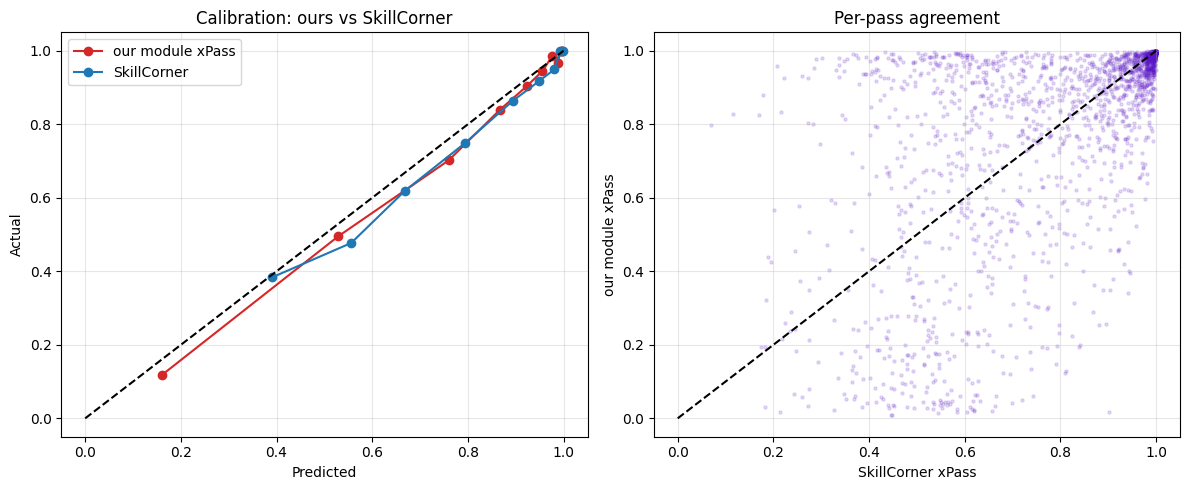

In [13]:
feat_rich = ["pass_distance", "pass_progression", "pass_angle", "passer_x", "abs_passer_y", "target_in_box"]
m2 = make_xgb(int(train_mask.sum()))
m2.fit(passes.loc[train_mask, feat_rich], passes.loc[train_mask, "pass_completed"].astype(int))
passes.loc[test_mask, "xpass_rich"] = m2.predict_proba(passes.loc[test_mask, feat_rich])[:, 1]

from xpass.xpass_features import TARGET_COLUMN as XPASS_TARGET_COLUMN, add_xpass_features, get_model_feature_columns as get_xpass_feature_columns
from xpass.train_skillcorner_xpass import make_xpass_pipeline

passes_featured = add_xpass_features(passes)
xpass_numeric, xpass_binary, xpass_categorical = get_xpass_feature_columns()
xpass_module_features = xpass_numeric + xpass_binary + xpass_categorical
for col in xpass_binary:
    passes_featured[col] = passes_featured[col].astype(float)
for col in xpass_categorical:
    passes_featured[col] = passes_featured[col].astype("string").fillna("missing")
passes_featured[XPASS_TARGET_COLUMN] = passes_featured[XPASS_TARGET_COLUMN].astype(bool)

m3 = make_xpass_pipeline("xgboost")
m3.fit(passes_featured.loc[train_mask, xpass_module_features],
       passes_featured.loc[train_mask, XPASS_TARGET_COLUMN].astype(int))
passes.loc[test_mask, "xpass_module_rich"] = m3.predict_proba(passes_featured.loc[test_mask, xpass_module_features])[:, 1]

report(y_test, passes.loc[test_mask, "xpass_simple"], "distance + progression")
report(y_test, passes.loc[test_mask, "xpass_rich"], "+ angle / position / box")
report(y_test, passes.loc[test_mask, "xpass_module_rich"], "module rich features")

available_numeric = [c for c in xpass_numeric if c in passes.columns and passes[c].notna().any()]
available_categorical = [c for c in xpass_categorical if c in passes.columns and passes[c].notna().any()]
print()
print(f"module feature columns: {len(xpass_module_features)} total "
      f"({len(xpass_numeric)} numeric, {len(xpass_binary)} binary, {len(xpass_categorical)} categorical)")
print("numeric inputs populated in this data:", available_numeric)
print("categorical inputs populated in this data:", available_categorical)

print()
print("feature importance (compact rich model):")
for f, imp in sorted(zip(feat_rich, m2.feature_importances_), key=lambda t: -t[1]):
    print(f"  {f:18s} {imp:.3f}")

# Compare against SkillCorner's provided xPass where it is available.
cmp = passes[test_mask & passes["skillcorner_xpass"].notna()].copy()
y_cmp = cmp["pass_completed"].astype(int)
if cmp.empty:
    print("No SkillCorner xPass values are available for the comparison sample.")
else:
    print()
    report(y_cmp, cmp["xpass_module_rich"], "our module xPass")
    report(y_cmp, cmp["skillcorner_xpass"], "SkillCorner xPass")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for col, color, lbl in [("xpass_module_rich", "#d62728", "our module xPass"), ("skillcorner_xpass", "#1f77b4", "SkillCorner")]:
        c = calibration_table(y_cmp, cmp[col], n_bins)
        axes[0].plot(c["pred"], c["actual"], "o-", color=color, label=lbl)
    axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    axes[0].set_title("Calibration: ours vs SkillCorner"); axes[0].legend(); axes[0].grid(alpha=.3)
    s = cmp.sample(min(6000, len(cmp)), random_state=0)
    axes[1].scatter(s["skillcorner_xpass"], s["xpass_module_rich"], s=5, alpha=0.15, color="#5B14C8")
    axes[1].plot([0, 1], [0, 1], "k--"); axes[1].set_xlabel("SkillCorner xPass"); axes[1].set_ylabel("our module xPass")
    axes[1].set_title("Per-pass agreement"); axes[1].grid(alpha=.3)
    fig.tight_layout(); plt.show()


## 9. PAx — Pass Above Expected

For each pass, `PAx = completed - xPass`. Positive values mean the pass was completed more often than expected given its difficulty. We aggregate PAx by player.


PAx uses xpass_module_rich.
players with >= 40 test passes: 26


,player_name,passes,completion,avg_xpass,pax_per_100
23,J. Brimmer,41,0.878,0.802,7.600
34,J. Valadon,48,0.875,0.828,4.659
57,R. Teague,48,0.896,0.872,2.346
24,J. Courtney-Perkins,50,0.840,0.818,2.196
19,F. Gallegos,58,0.759,0.738,2.088
6,A. Thurgate,65,0.846,0.836,0.979
22,H. Sakai,80,0.700,0.692,0.774
4,A. Popovic,60,0.800,0.794,0.647
48,N. Pijnaker,91,0.780,0.776,0.436
58,T. Imai,59,0.661,0.658,0.287


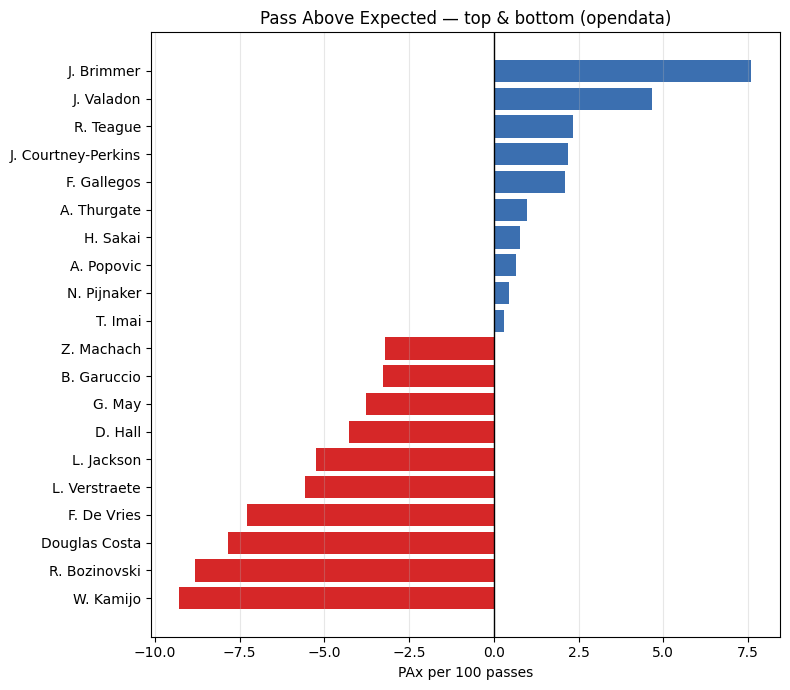

In [14]:
test = passes[test_mask].copy()
pax_prediction_col = "xpass_module_rich" if "xpass_module_rich" in test.columns else "xpass_rich"
test["pax"] = test["pass_completed"].astype(float) - test[pax_prediction_col]
min_passes = 200 if DATA_SOURCE == "local" else 40
name_col = "player_name" if "player_name" in test.columns else "player_id"
grp = (test.groupby(name_col, dropna=False)
           .agg(passes=("pax", "size"), completion=("pass_completed", "mean"),
                avg_xpass=(pax_prediction_col, "mean"), pax_per_100=("pax", lambda s: s.mean() * 100))
           .reset_index())
grp = grp[grp["passes"] >= min_passes].sort_values("pax_per_100", ascending=False)
print(f"PAx uses {pax_prediction_col}.")
print(f"players with >= {min_passes} test passes: {len(grp)}")
show = pd.concat([grp.head(10), grp.tail(10)]) if len(grp) else grp
display(show.round(3))

if len(show):
    fig, ax = plt.subplots(figsize=(8, 7))
    order = show.iloc[::-1]
    colors = np.where(order["pax_per_100"] >= 0, "#3b6fb0", "#d62728")
    ax.barh(order[name_col].astype(str), order["pax_per_100"], color=colors)
    ax.axvline(0, color="black", lw=1); ax.set_xlabel("PAx per 100 passes")
    ax.set_title(f"Pass Above Expected — top & bottom ({DATA_SOURCE})"); ax.grid(axis="x", alpha=.3)
    fig.tight_layout(); plt.show()
